In [1]:
!pip install kiss-icp

You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.


In [2]:
!pip install open3d

You should consider upgrading via the '/opt/conda/bin/python -m pip install --upgrade pip' command.


In [3]:
import open3d as o3d
import numpy as np
import copy
import os
from kiss_icp.pipeline import OdometryPipeline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [10]:
import open3d as o3d
import numpy as np
import os

# List of 65 point cloud files (Replace with actual filenames)
point_cloud_files = os.listdir("output_pcds")
point_cloud_files = [f"output_pcds/{f}" for f in point_cloud_files][:2]

# Load the first point cloud as the reference
global_map = o3d.io.read_point_cloud(point_cloud_files[0])
global_transformation = np.eye(4)  # Identity matrix

# ICP Parameters
threshold = 0.02  # Maximum correspondence distance for ICP
icp_criteria = o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)

for i in range(1, len(point_cloud_files)):
    print(f"Registering frame {i} to frame {i-1}")

    # Load the next point cloud
    source = o3d.io.read_point_cloud(point_cloud_files[i])

    # Perform ICP to align source to global_map
    reg_p2p = o3d.pipelines.registration.registration_icp(
        source, global_map, threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        icp_criteria
    )

    # Apply the transformation to align the current frame
    source.transform(reg_p2p.transformation)

    # Update the cumulative transformation
    global_transformation = reg_p2p.transformation @ global_transformation

    # Merge transformed cloud into the global map
    global_map += source

# Save the final registered map
o3d.io.write_point_cloud("final_registered_map.pcd", global_map)

# Visualize the final registered point cloud map
o3d.visualization.draw_geometries([global_map])


Registering frame 1 to frame 0
Registering frame 2 to frame 1
Registering frame 3 to frame 2
Registering frame 4 to frame 3
Registering frame 5 to frame 4
Registering frame 6 to frame 5
Registering frame 7 to frame 6
Registering frame 8 to frame 7
Registering frame 9 to frame 8
Registering frame 10 to frame 9
Registering frame 11 to frame 10
Registering frame 12 to frame 11
Registering frame 13 to frame 12
Registering frame 14 to frame 13
Registering frame 15 to frame 14
Registering frame 16 to frame 15
Registering frame 17 to frame 16
Registering frame 18 to frame 17
Registering frame 19 to frame 18
Registering frame 20 to frame 19
Registering frame 21 to frame 20
Registering frame 22 to frame 21
Registering frame 23 to frame 22
Registering frame 24 to frame 23
Registering frame 25 to frame 24
Registering frame 26 to frame 25
Registering frame 27 to frame 26
Registering frame 28 to frame 27
Registering frame 29 to frame 28
Registering frame 30 to frame 29
Registering frame 31 to frame

error: XDG_RUNTIME_DIR not set in the environment.


Registering frame 1 to frame 0
Registering frame 2 to frame 1
Registering frame 3 to frame 2
Registering frame 4 to frame 3
Registering frame 5 to frame 4
Registering frame 6 to frame 5
Registering frame 7 to frame 6
Registering frame 8 to frame 7
Registering frame 9 to frame 8
Registering frame 10 to frame 9
Registering frame 11 to frame 10
Registering frame 12 to frame 11
Registering frame 13 to frame 12
Registering frame 14 to frame 13
Registering frame 15 to frame 14
Registering frame 16 to frame 15
Registering frame 17 to frame 16
Registering frame 18 to frame 17
Registering frame 19 to frame 18
Registering frame 20 to frame 19
Registering frame 21 to frame 20
Registering frame 22 to frame 21
Registering frame 23 to frame 22
Registering frame 24 to frame 23
Registering frame 25 to frame 24
Registering frame 26 to frame 25
Registering frame 27 to frame 26
Registering frame 28 to frame 27
Registering frame 29 to frame 28
Registering frame 30 to frame 29
Registering frame 31 to frame

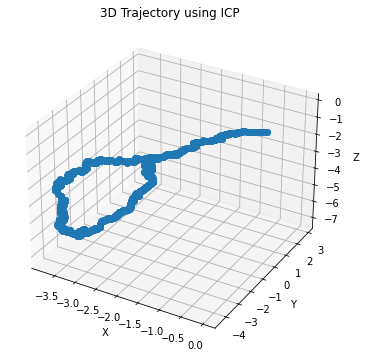

In [8]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# List of sequential point cloud files (Replace with actual filenames)
point_cloud_files = os.listdir("output_pcds")
point_cloud_files = [f"output_pcds/{f}" for f in point_cloud_files]

# Load first point cloud as reference
global_map = o3d.io.read_point_cloud(point_cloud_files[0])
global_transformation = np.eye(4)  # Identity transformation

# Store trajectory positions
trajectory = [global_transformation[:3, 3]]  # Store initial position

# ICP Parameters
threshold = 0.02  # Max correspondence distance for ICP
icp_criteria = o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)

for i in range(1, len(point_cloud_files)):
    print(f"Registering frame {i} to frame {i-1}")

    # Load the next point cloud
    source = o3d.io.read_point_cloud(point_cloud_files[i])

    # Perform ICP to align source to global_map
    reg_p2p = o3d.pipelines.registration.registration_icp(
        source, global_map, threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        icp_criteria
    )

    # Update transformation
    global_transformation = reg_p2p.transformation @ global_transformation

    # Store trajectory position
    trajectory.append(global_transformation[:3, 3])

    # Transform the source and merge into the global map
    source.transform(global_transformation)
    global_map += source

# Convert trajectory to NumPy array
trajectory = np.array(trajectory)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], marker="o", linestyle="-")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D Trajectory using ICP")
plt.show()



Registering frame 1 to frame 0
Registering frame 2 to frame 1
Registering frame 3 to frame 2
Registering frame 4 to frame 3
Registering frame 5 to frame 4
Registering frame 6 to frame 5
Registering frame 7 to frame 6
Registering frame 8 to frame 7
Registering frame 9 to frame 8
Registering frame 10 to frame 9
Registering frame 11 to frame 10
Registering frame 12 to frame 11
Registering frame 13 to frame 12
Registering frame 14 to frame 13
Registering frame 15 to frame 14
Registering frame 16 to frame 15
Registering frame 17 to frame 16
Registering frame 18 to frame 17
Registering frame 19 to frame 18
Registering frame 20 to frame 19
Registering frame 21 to frame 20
Registering frame 22 to frame 21
Registering frame 23 to frame 22
Registering frame 24 to frame 23
Registering frame 25 to frame 24
Registering frame 26 to frame 25
Registering frame 27 to frame 26
Registering frame 28 to frame 27
Registering frame 29 to frame 28
Registering frame 30 to frame 29
Registering frame 31 to frame

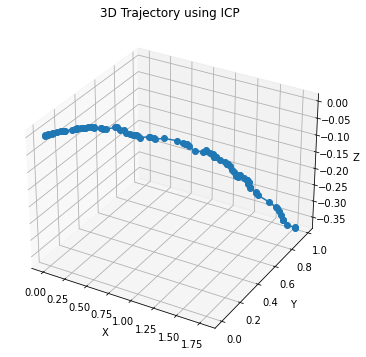

In [12]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# List of sequential point cloud files (Replace with actual filenames)
point_cloud_files = os.listdir("output_pcds")
point_cloud_files = [f"output_pcds/{f}" for f in point_cloud_files][500:700:2]

# Load first point cloud as reference
global_map = o3d.io.read_point_cloud(point_cloud_files[0])
global_transformation = np.eye(4)  # Identity transformation

# Store trajectory positions
trajectory = [global_transformation[:3, 3]]  # Store initial position

# ICP Parameters
threshold = 0.02  # Max correspondence distance for ICP
icp_criteria = o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=200)

for i in range(1, len(point_cloud_files)):
    print(f"Registering frame {i} to frame {i-1}")

    # Load the next point cloud
    source = o3d.io.read_point_cloud(point_cloud_files[i])

    # Perform ICP to align source to global_map
    reg_p2p = o3d.pipelines.registration.registration_icp(
        source, global_map, threshold, np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        icp_criteria
    )

    # Update transformation
    global_transformation = reg_p2p.transformation @ global_transformation

    # Store trajectory position
    trajectory.append(global_transformation[:3, 3])

    # Transform the source and merge into the global map
    source.transform(global_transformation)
    global_map += source

# Convert trajectory to NumPy array
trajectory = np.array(trajectory)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], marker="o", linestyle="-")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.title("3D Trajectory using ICP")
plt.show()



In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from kiss_icp.pipeline import OdometryPipeline

# Initialize the KISS-ICP odometry pipeline
pipeline = OdometryPipeline()
point_cloud_files = os.listdir("output_pcds")
point_cloud_files = [f"output_pcds/{f}" for f in point_cloud_files][500:700:2]

# Store estimated trajectory
trajectory = []

for i, file in enumerate(point_cloud_files):
    print(f"Processing frame {i+1}/{len(point_cloud_files)}")

    # Load the point cloud
    pcd = o3d.io.read_point_cloud(file)
    points = np.asarray(pcd.points)

    # Register frame using KISS-ICP
    pose = pipeline.register_frame(points)

    # Store trajectory position (Extract translation from the pose matrix)
    trajectory.append(pose[:3, 3])

# Convert trajectory to NumPy array
trajectory = np.array(trajectory)

# Plot estimated trajectory
plt.figure(figsize=(8, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], marker="o", linestyle="-", label="KISS-ICP Trajectory")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Estimated Trajectory using KISS-ICP")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
def draw_registration_result(source, target, transformation):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.paint_uniform_color([1, 0.706, 0])
    target_temp.paint_uniform_color([0, 0.651, 0.929])
    source_temp.transform(transformation)
    o3d.visualization.draw_geometries([source_temp, target_temp],
                                      zoom=0.4459,
                                      front=[0.9288, -0.2951, -0.2242],
                                      lookat=[1.6784, 2.0612, 1.4451],
                                      up=[-0.3402, -0.9189, -0.1996])

In [6]:
# demo_icp_pcds = o3d.data.DemoICPPointClouds()
point_cloud_files = os.listdir("output_pcds")
point_cloud_files = [f"output_pcds/{f}" for f in point_cloud_files]
demo_icp_pcds = [point_cloud_files[0], point_cloud_files[1]]
source = o3d.io.read_point_cloud(demo_icp_pcds[0])
target = o3d.io.read_point_cloud(demo_icp_pcds[1])
threshold = 0.02
trans_init = np.asarray([[0.862, 0.011, -0.507, 0.5],
                         [-0.139, 0.967, -0.215, 0.7],
                         [0.487, 0.255, 0.835, -1.4], [0.0, 0.0, 0.0, 1.0]])
draw_registration_result(source, target, trans_init)

error: XDG_RUNTIME_DIR not set in the environment.


In [1]:
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(
    source, target, threshold, trans_init)
print(evaluation)

Initial alignment


NameError: name 'o3d' is not defined

In [2]:
print("Apply point-to-point ICP")
reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())
print(reg_p2p)
print("Transformation is:")
print(reg_p2p.transformation)
draw_registration_result(source, target, reg_p2p.transformation)

Apply point-to-point ICP


NameError: name 'o3d' is not defined

In [14]:
pipeline = OdometryPipeline()

# Example: Load a set of point cloud files
demo_icp_pcds = o3d.data.DemoICPPointClouds()
# source = o3d.io.read_point_cloud(demo_icp_pcds.paths[0])
# target = o3d.io.read_point_cloud(demo_icp_pcds.paths[1])

point_cloud_files = [demo_icp_pcds.paths[0], demo_icp_pcds.paths[1]] 

# Store poses for visualization
poses = []

for file in point_cloud_files:
    # Load point cloud
    pcd = o3d.io.read_point_cloud(file)
    points = np.asarray(pcd.points)

    # Process the frame with KISS-ICP
    pose = pipeline.register_frame(points)

    # Store pose
    poses.append(pose)

# Print final pose estimate
print("Final pose:", poses[-1])

AttributeError: 'str' object has no attribute 'data_dir'

In [ ]:
import matplotlib.pyplot as plt

poses_array = np.array([pose[:3, 3] for pose in poses])  # Extract x, y, z from poses

plt.plot(poses_array[:, 0], poses_array[:, 1], marker="o", label="KISS-ICP trajectory")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.grid(True)
plt.title("KISS-ICP Estimated Trajectory")
plt.show()
